# Startup Market Analysis

## Project overview
This exploratory analysis examines how startup funding varies across market segments, funding types, and time. It combines data cleaning, segmentation, and visualization to identify investment patterns and inform further evaluation of potential opportunities in a historical, pre-2015 context.

Tools: Python, pandas, NumPy, Matplotlib, and Seaborn

### Data overview
The analysis uses two related tables: company-level records covering industries, locations, funding amounts, rounds, and dates; and annual totals of funds returned by funding type. Investment amounts are recorded in US dollars, while returned amounts are provided in millions of US dollars and converted where needed for comparison.
Data source: Educational datasets provided by Yandex Practicum.

### Contents <a class="anchor" id="main"></a>
1. [Data loading and preprocessing](#1-bullet)
2. [Feature engineering](#2-bullet)
3. [Outlier handling and analysis](#3-bullet)
4. [Trend analysis](#4-bullet)
5. [Conclusions and recommendations](#5-bullet)

## 1. Data loading and preprocessing <a class="anchor" id="1-bullet"></a>

#### 1.1 General information
Review the dataset size, its consistency with the description, missing values, and data types. Note any other characteristics that may require attention during preprocessing.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Import data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import the library for calculating the phi_k correlation coefficient
from phik import phik_matrix

In [2]:
# Load the data
cb_investments = pd.read_csv(
    "cb_investments.zip",
    sep=';',
    compression='zip',
    low_memory=False
)
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
cb_returns = pd.read_csv("cb_returns.csv", sep=',')
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [4]:
# Display information about the cb_investments DataFrame
cb_investments.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

The `cb_investments` dataset contains 40 columns and 54,294 rows describing companies and their funding.

Review of data types and data quality:
- **Floating-point values (float64).** Most columns use the float64 data type.
- **Date fields.** The dataset includes date fields (`founded_at`, `first_funding_at`, `last_funding_at`, and `mid_funding_at`), but they are stored as strings and can be converted to datetime when needed.
- **String values.** The `funding_total_usd` column contains funding amounts stored as strings, so it may need to be converted to a numeric type for further analysis.
- **Missing values.** Some date values are missing, as are values in `state_code`, `participants`, and `mid_funding_at`.
- **Column names.** Names follow snake_case and require no preprocessing.

Most columns use appropriate data types.

In [5]:
# Display information about the cb_returns DataFrame
cb_returns.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


The `cb_returns` dataset contains 14 columns and 15 rows describing returned funds. Its small size indicates that the data is aggregated by year.

Review of data types and data quality:
- **Floating-point values (float64).** All columns except the year use this numeric data type for financial amounts.
- **Integer values (int64).** The `year` column contains the observation year and uses int64, which is appropriate for calendar years.
- **Missing values.** There are no missing values.
- **Column names.** Names follow snake_case and require no preprocessing.

Most columns use appropriate data types, and the dataset has no missing values.

#### 1.2 Data preprocessing
Check whether column names accurately describe their contents and follow a convenient naming convention. Standardize them where necessary.

In [6]:
# Display all column names in cb_investments
cb_investments.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='str')

In [7]:
# Display all column names in cb_returns
cb_returns.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='str')

In [8]:
# Remove extra whitespace.
cb_investments.columns = cb_investments.columns.str.strip()

In [9]:
# Remove thousands separators and convert to a numeric type.
cb_investments['funding_total_usd'] = (
    cb_investments['funding_total_usd']
    .str.replace(',', '', regex=False)   # Remove thousands separators
    .str.strip()                         # Remove whitespace
)

cb_investments['funding_total_usd'] = pd.to_numeric(
    cb_investments['funding_total_usd'],
    errors='coerce'
)

In [10]:
# Check the result.
cb_investments['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

In [11]:
# Check the result.
cb_investments['funding_total_usd'].dtype

dtype('float64')

In [12]:
# Convert date and time columns to appropriate data types.
date_columns = [
    'founded_at',
    'first_funding_at',
    'last_funding_at',
    'mid_funding_at'
]

for col in date_columns:
    cb_investments[col] = pd.to_datetime(cb_investments[col], errors='coerce')

In [13]:
# Check the conversion to datetime
cb_investments[date_columns].dtypes

founded_at          datetime64[us]
first_funding_at    datetime64[us]
last_funding_at     datetime64[us]
mid_funding_at      datetime64[us]
dtype: object

Set the `year` column as the index of the `cb_returns` dataset.

In [14]:
# Set year as the index of cb_returns
cb_returns = cb_returns.set_index('year')

In [15]:
# Check the result
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [16]:
# Clean text fields and fill missing values with placeholders where needed.
columns_to_fillna = ['category_list', 'market', 'country_code', 'state_code', 'region', 'city']

for col in columns_to_fillna:
    cb_investments[col] = cb_investments[col].fillna('unknown')

Assess data completeness and determine whether the available data is sufficient to meet the project objectives. What percentage of the data was removed?

In [17]:
# Check missing values after inserting placeholders
missing_values = pd.DataFrame({
    'missing_count': cb_investments.isna().sum(),
    'missing_percent': cb_investments.isna().mean() * 100
})

missing_values = missing_values.sort_values(
    by='missing_percent',
    ascending=False
)

missing_values.round(2)

,missing_count,missing_percent
mid_funding_at,24006,44.21
participants,23821,43.87
founded_month,15812,29.12
founded_quarter,15812,29.12
founded_at,15740,28.99
founded_year,15740,28.99
funding_total_usd,13387,24.66
homepage_url,8305,15.30
status,6170,11.36
name,4857,8.95


In [18]:
# Fill missing status values.
cb_investments['status'] = cb_investments['status'].fillna('unknown')

In [19]:
# Check for exact duplicate rows.
cb_investments.duplicated().sum()

np.int64(4855)

In [20]:
# Remove exact duplicate rows.
cb_investments = cb_investments.drop_duplicates()

In [21]:
# Count missing funding_total_usd values.
cb_investments['funding_total_usd'].isna().sum()

np.int64(8532)

In [22]:
# Remove rows with missing funding_total_usd.
cb_investments = cb_investments.dropna(subset=['funding_total_usd'])

In [23]:
# Check for missing funding_total_usd values.
cb_investments['funding_total_usd'].isna().sum()

np.int64(0)

In [24]:
# Fill missing mid_funding_at values using first_funding_at and last_funding_at.
# Use the approximate midpoint between the two dates.
cb_investments['mid_funding_at'] = cb_investments['mid_funding_at'].fillna(
    cb_investments['first_funding_at'] + 
    (cb_investments['last_funding_at'] - cb_investments['first_funding_at']) / 2)

In [25]:
# Check the remaining number of missing values
cb_investments['mid_funding_at'].isna().sum()

np.int64(0)

In [26]:
# Calculate the percentage of rows removed
initial_rows = 54294
current_rows = cb_investments.shape[0]

percent_dropped = round(((initial_rows - current_rows) / initial_rows * 100),2)
percent_dropped

24.66

#### Key findings
- Missing values were found in text columns. Missing `status` values were filled with "unknown" because this field is used to analyze company status. Missing values in `name` and `homepage_url` were left unchanged because they do not affect the subsequent analysis.
- Missing values in other text columns were filled with "unknown" to simplify further analysis.
- The `funding_total_usd` column contained 8,532 missing values. These rows were removed because they provided no information about funding amounts.
- Missing `mid_funding_at` values were replaced with the midpoint between `first_funding_at` and `last_funding_at`. No missing values remained in this column afterward.
- Rows with missing total funding were removed during preprocessing. Overall, approximately 24.7% of the data was discarded. More than 40,000 observations remained, providing a sufficient basis for further analysis.

In [27]:
# Remove remaining leading and trailing whitespace
cb_investments['market'] = cb_investments['market'].str.strip()

In [28]:
# Check variations of Software
cb_investments[
    cb_investments['market'].str.contains(r'^\s*Software\s*$', na=False)]['market'].value_counts()

market
Software    4812
Name: count, dtype: int64

In [29]:
# Check variations of Software
cb_investments['market'].str.startswith(' ').sum()
cb_investments['market'].str.endswith(' ').sum()

np.int64(0)

#### [Back to contents](#main)

## 2. Feature engineering <a class="anchor" id="2-bullet"></a>
Feature engineering transforms the original data into new analytical features that simplify the analysis. Here, companies are grouped by funding duration and market segment.

### 2.1 Groups by funding duration
Divide companies into three groups: a single funding round, multiple rounds within one year, and funding over more than one year.

In [30]:
# Calculate funding duration
cb_investments['funding_duration'] = cb_investments['last_funding_at'] - cb_investments['first_funding_at']

In [31]:
# Inspect the resulting groups
cb_investments[['funding_rounds','funding_duration']].head(10)

,funding_rounds,funding_duration
0,1.0,0 days
1,1.0,0 days
2,1.0,0 days
3,3.0,347 days
4,1.0,0 days
5,1.0,0 days
6,4.0,108 days
7,1.0,0 days
8,1.0,0 days
9,2.0,152 days


In [32]:
# Divide companies into the three required groups
def funding_group(row):

    if row['funding_rounds'] == 1:
        return 'single'

    elif row['funding_duration'] <= pd.Timedelta(days=365):
        return 'up_to_year'

    else:
        return 'more_than_year'

In [33]:
cb_investments['funding_group'] = cb_investments.apply(funding_group, axis=1)

In [34]:
# Inspect the first rows
cb_investments[['funding_rounds','funding_duration','funding_group']].head(10)

,funding_rounds,funding_duration,funding_group
0,1.0,0 days,single
1,1.0,0 days,single
2,1.0,0 days,single
3,3.0,347 days,up_to_year
4,1.0,0 days,single
5,1.0,0 days,single
6,4.0,108 days,up_to_year
7,1.0,0 days,single
8,1.0,0 days,single
9,2.0,152 days,up_to_year


In [35]:
# Count companies in each group
cb_investments['funding_group'].value_counts()

funding_group
single            24113
more_than_year    12293
up_to_year         4501
Name: count, dtype: int64

In [36]:
# Calculate each group's share
companies_share = cb_investments['funding_group'].value_counts(normalize=True)*100

<Axes: title={'center': 'Share of Companies by Funding Duration'}>

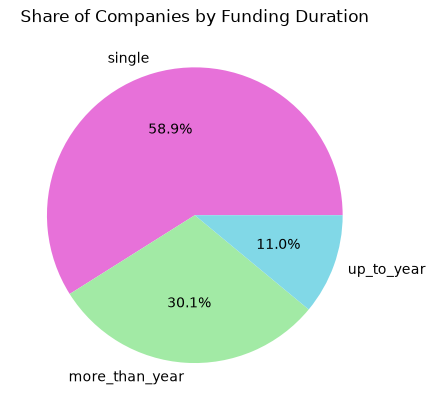

In [37]:
# Create a chart
colors = ['#E771D9', '#A2EAA5', '#81D8E7']
companies_share.plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel='',
    colors=colors,
    title='Share of Companies by Funding Duration')

In [38]:
# Calculate investment totals for these groups
investments_share = cb_investments.groupby('funding_group')['funding_total_usd'].sum()

In [39]:
# Calculate each group's share
investments_share = investments_share / investments_share.sum() * 100

<Axes: title={'center': 'Share of Investment by Funding Duration'}>

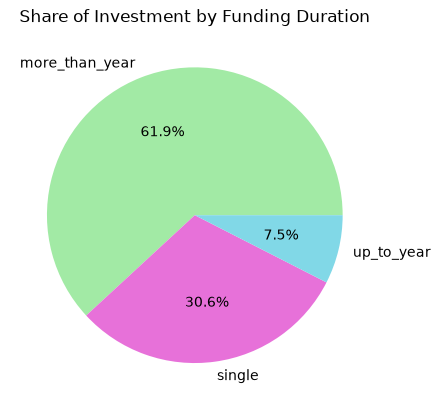

In [40]:
# Create a chart
colors = ['#A2EAA5', '#E771D9', '#81D8E7']
investments_share.plot(
    kind='pie',
    autopct='%1.1f%%',
    ylabel='',
    colors=colors,
    title='Share of Investment by Funding Duration')

#### Key findings
- Companies were divided into three groups by funding duration. Most companies (24,113) received funding in a single round. A substantial number (12,293) raised funding over more than one year. The smallest group comprised companies with multiple funding rounds within one year (4,501).
- Companies that raise funding over more than one year account for the largest share of investment (61.9%).
- Companies with a single round receive approximately 30% of investment.
- Companies funded within one year receive the smallest share, at 7.5%.

### 2.2 Identifying mid-sized and niche market segments
Calculate the number of market segments in each category.

In [41]:
# Count companies in each market segment
market_counts = cb_investments['market'].value_counts()
market_counts.head(10)

market
Software               4812
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Name: count, dtype: int64

In [42]:
# Divide segments into groups
def market_group(count):
    if count > 120:
        return 'mass'
    elif 35 <= count <= 120:
        return 'mid'
    else:
        return 'niche'

market_groups = market_counts.apply(market_group)
market_groups.head(10)

market
Software               mass
Biotechnology          mass
unknown                mass
Mobile                 mass
E-Commerce             mass
Curated Web            mass
Enterprise Software    mass
Health Care            mass
Clean Technology       mass
Games                  mass
Name: count, dtype: str

In [43]:
# Count market segments in each group
market_groups.value_counts()

count
niche    289
mid       57
mass      49
Name: count, dtype: int64

<Axes: title={'center': 'Number of Segments by Market Category'}, xlabel='Type', ylabel='Count'>

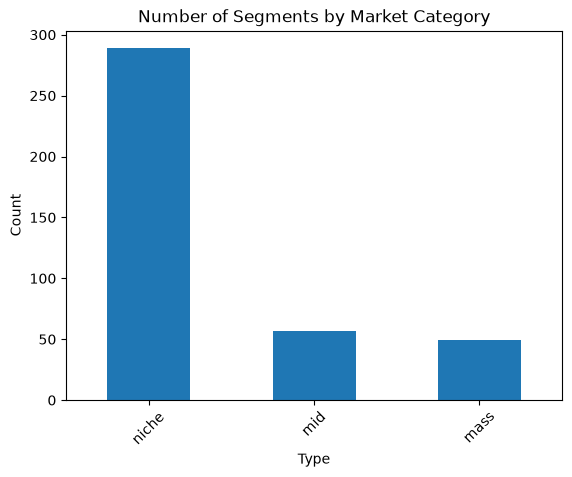

In [44]:
# Plot the distribution of segments across market categories.
market_groups.value_counts().plot(
    kind='bar',
    rot = 45,
    ylabel='Count',
    xlabel='Type',
    title='Number of Segments by Market Category')

In [45]:
# Keep original market names only for mass-market segments.
# Replace other segment names with niche or mid, as appropriate.
mid_markets = market_groups[market_groups == 'mid'].index
niche_markets = market_groups[market_groups == 'niche'].index

In [46]:
cb_investments.loc[
    cb_investments['market'].isin(mid_markets),
    'market'
] = 'mid'

cb_investments.loc[
    cb_investments['market'].isin(niche_markets),
    'market'
] = 'niche'

In [47]:
cb_investments['market'].value_counts().head(20)

market
Software               4812
mid                    3841
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Advertising            1107
Hardware + Software    1062
Social Media           1003
Health and Wellness     873
Education               844
niche                   830
Finance                 828
Analytics               667
Manufacturing           596
Name: count, dtype: int64

<Axes: title={'center': 'Share of Companies by Market Type'}, xlabel='Segment type', ylabel='Share of companies'>

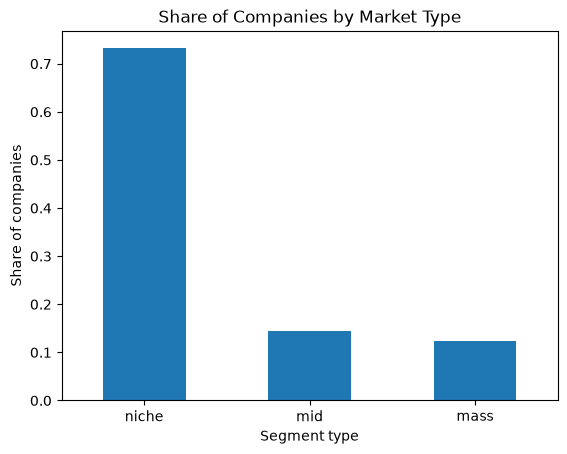

In [48]:
market_groups.value_counts(normalize=True).plot(
    kind='bar',
    rot=0,
    ylabel='Share of companies',
    xlabel='Segment type',
    title='Share of Companies by Market Type')

In [49]:
market_stats = market_counts.to_frame(name='company_count')
market_stats['group'] = market_groups
market_stats.head()

,company_count,group
market,,
Software,4812,mass
Biotechnology,3590,mass
unknown,2503,mass
Mobile,2344,mass
E-Commerce,1866,mass


In [50]:
companies_by_group = market_stats.groupby('group')['company_count'].sum()
companies_by_group

group
mass     36236
mid       3841
niche      830
Name: company_count, dtype: int64

In [51]:
# Convert counts to percentage shares
company_share = (companies_by_group / companies_by_group.sum()) * 100
company_share

group
mass     88.581416
mid       9.389591
niche     2.028993
Name: company_count, dtype: float64

<Axes: title={'center': 'Share of Companies Operating in Each Market Type'}, xlabel='Segment type', ylabel='Share of companies'>

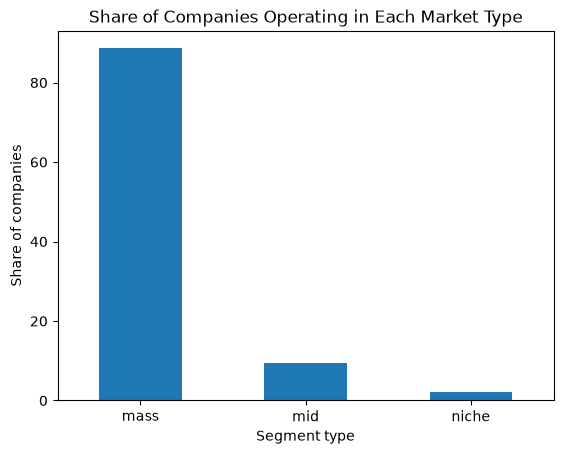

In [52]:
# Create a chart
company_share.plot(
    kind='bar',
    rot=0,
    ylabel='Share of companies',
    xlabel='Segment type',
    title='Share of Companies Operating in Each Market Type')

#### Key findings
- Most market segments are niche segments (714).
- There are 81 mid-sized segments and only 54 mass-market segments.
- This indicates a highly fragmented market with many specialized areas, each containing relatively few companies.
- Market segments were grouped by company count. Mass-market segments (more than 120 companies) retained their original names. Mid-sized segments were combined into the `mid` category, while smaller segments were combined into `niche`. This reduced the number of unique segments and simplified further analysis.
- The distribution of segments differs substantially from the distribution of companies across them. Although there are relatively few mass-market segments (49), they contain more than 80% of startups. These markets serve broad audiences and offer more opportunities for scaling. Niche segments are numerous, but each contains relatively few companies.

#### [Back to contents](#main)

## 3. Outlier handling and analysis <a class="anchor" id="3-bullet"></a>
Identify typical and unusual total funding amounts per company, define the study period, exclude anomalies, and analyze funding volumes and prevalence.

### 3.1 Analyzing and flagging outliers in each segment
Use a visualization of the preprocessed `funding_total_usd` column to assess typical and unusual total funding amounts per company. Specify the range of typical values.
Identify companies with unusually high or low total funding using the IQR method separately for each segment.

In [53]:
cb_investments['funding_total_usd']

0        90000000.0
1         2000000.0
2         9000000.0
3         7700000.0
4          540000.0
            ...    
49433     1500000.0
49434     9000000.0
49435      250000.0
49436    34000000.0
49437       11500.0
Name: funding_total_usd, Length: 40907, dtype: float64

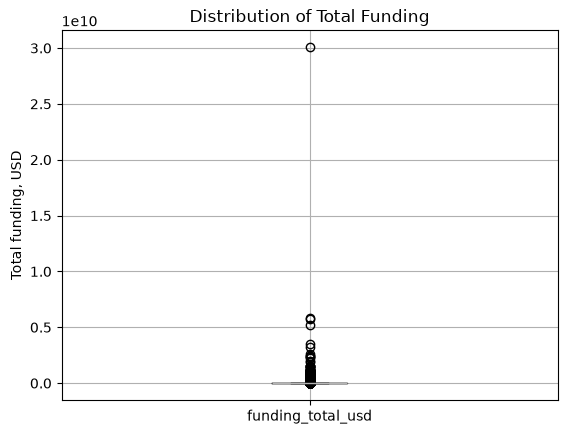

In [54]:
# Inspect investment ranges
cb_investments.boxplot(column='funding_total_usd')
plt.title('Distribution of Total Funding')
plt.ylabel('Total funding, USD')
plt.show()

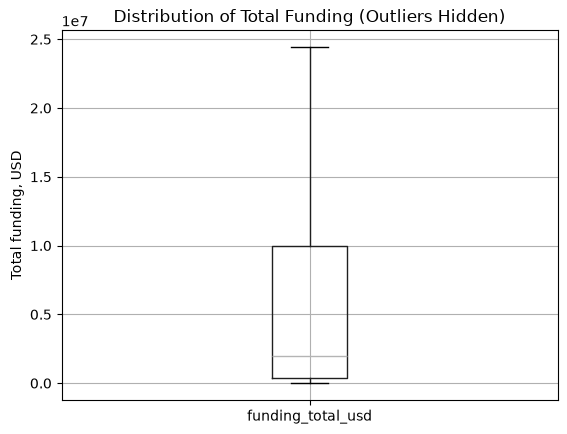

In [55]:
# Inspect investment ranges
cb_investments.boxplot(column='funding_total_usd', showfliers=False)
plt.title('Distribution of Total Funding (Outliers Hidden)')
plt.ylabel('Total funding, USD')
plt.show()

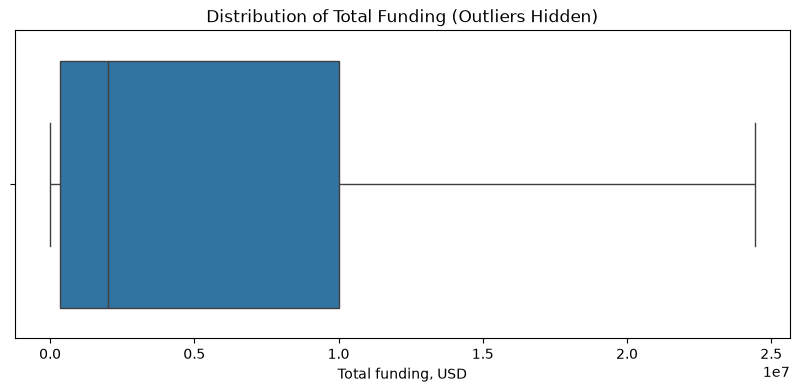

In [56]:
# Inspect investment ranges
plt.figure(figsize=(10, 4))
sns.boxplot(x=cb_investments['funding_total_usd'], showfliers=False)
plt.title('Distribution of Total Funding (Outliers Hidden)')
plt.xlabel('Total funding, USD')
plt.show()

#### Key findings
- Total funding is strongly right-skewed: most observations have relatively low values, while large deals create a long right tail.
- The upper whisker of the box plot suggests that typical total funding amounts extend to approximately $25 million.
- The median is approximately $2 million, and most deals are below $10 million, indicating a right-skewed distribution with substantial outliers.

In [57]:
cb_investments[cb_investments['market'].isin(['mid', 'niche'])]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_duration,funding_group
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single
42,CESC,https://www.cesc.co.in/,|Utilities|,niche,80000000.0,operating,IND,unknown,Kolkata,Kolkata,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single
53,Bristol-Myers Squibb,http://www.bms.com,|Health and Wellness|Pharmaceuticals|Biotechno...,mid,15510000.0,operating,USA,NY,New York City,New York,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single
58,General Electric,http://www.ge.com,|Media|Finance|Electronics|,mid,2000000.0,operating,USA,CT,Hartford,Fairfield,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single
63,The Exchange,http://www.shopmyexchange.com/,|Politics|,niche,940000000.0,operating,USA,TX,Dallas,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,991 days,more_than_year
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49384,Aequus Pharmaceuticals,http://aequuspharma.ca,|Pharmaceuticals|,mid,4200000.0,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single
49395,PicaSolar,http://picasolar.com/,|Solar|,niche,1200000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single
49420,Pond-Deshpande Centre,http://www.ponddeshpande.ca/,|Entrepreneur|,niche,500000.0,operating,CAN,NB,Fredericton,Fredericton,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single
49422,Creamfinance,https://www.creamfinance.com/,|Financial Services|,mid,6200000.0,operating,LVA,unknown,Riga,Riga,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0 days,single


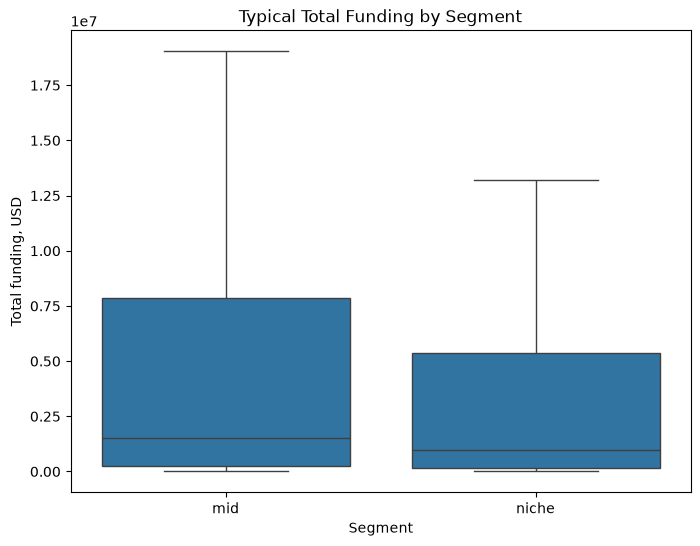

In [58]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=cb_investments[cb_investments['market'].isin(['mid', 'niche'])],
    x='market',
    y='funding_total_usd',
    showfliers=False
)

plt.title('Typical Total Funding by Segment')
plt.xlabel('Segment')
plt.ylabel('Total funding, USD')
plt.show()

In [59]:
# Calculate the bounds for each segment
q1 = cb_investments.groupby('market')['funding_total_usd'].quantile(0.25)
q3 = cb_investments.groupby('market')['funding_total_usd'].quantile(0.75)

iqr = q3 - q1

lower_mid = q1['mid'] - 1.5 * iqr['mid']
upper_mid = q3['mid'] + 1.5 * iqr['mid']

lower_niche = q1['niche'] - 1.5 * iqr['niche']
upper_niche = q3['niche'] + 1.5 * iqr['niche']

print('mid:', lower_mid, upper_mid)
print('niche:', lower_niche, upper_niche)

mid: -11150000.0 19250000.0
niche: -7706591.25 13244318.75


In [60]:
cb_investments['is_outlier'] = False

In [61]:
# Flag outliers in mid
cb_investments.loc[
    (cb_investments['market'] == 'mid') &
    (
        (cb_investments['funding_total_usd'] < lower_mid) |
        (cb_investments['funding_total_usd'] > upper_mid)
    ),
    'is_outlier'
] = True

In [62]:
# Flag outliers in niche
cb_investments.loc[
    (cb_investments['market'] == 'niche') &
    (
        (cb_investments['funding_total_usd'] < lower_niche) |
        (cb_investments['funding_total_usd'] > upper_niche)
    ),
    'is_outlier'
] = True

In [63]:
outlier_share = (
    cb_investments[cb_investments['market'].isin(['mid','niche'])]
    .groupby('market')['is_outlier']
    .mean()
    .sort_values(ascending=False))
outlier_share

market
niche    0.159036
mid      0.144754
Name: is_outlier, dtype: float64

In [64]:
cb_investments['is_outlier'] = False

In [65]:
for market in cb_investments['market'].unique():

    data = cb_investments.loc[
        cb_investments['market'] == market,
        'funding_total_usd'
    ]

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    cb_investments.loc[
        (cb_investments['market'] == market) &
        (
            (cb_investments['funding_total_usd'] < lower) |
            (cb_investments['funding_total_usd'] > upper)
        ),
        'is_outlier'
    ] = True

In [66]:
cb_investments['is_outlier'].mean()

np.float64(0.12819321876451464)

In [67]:
cb_investments.groupby('market')['is_outlier'].mean().sort_values(ascending=False)

market
Real Estate             0.172043
Entertainment           0.166667
Consulting              0.166189
Search                  0.164948
Cloud Computing         0.164474
Photography             0.161765
SaaS                    0.161765
Technology              0.159664
Video                   0.159574
niche                   0.159036
Travel                  0.154545
Networking              0.153846
Internet                0.153527
Big Data                0.153333
Marketplaces            0.153061
unknown                 0.149021
mid                     0.144754
E-Commerce              0.144159
Apps                    0.143498
Automotive              0.141935
Medical                 0.139073
Sports                  0.137255
Social Media            0.135593
News                    0.132890
Education               0.132701
Fashion                 0.132013
Mobile                  0.131826
Hospitality             0.130952
Health and Wellness     0.129439
Messaging               0.128814
Cle

#### Key findings
- Box plots with outliers hidden show similar ranges of typical total funding for the `mid` and `niche` groups. Their medians are also comparable, although niche segments have a slightly higher upper boundary for typical values.
- Total funding is strongly right-skewed: most companies receive relatively small investments, while a small number of startups raise very large amounts.
- The IQR method identifies a slightly higher outlier share in `niche` (15.1%) than in `mid` (14.1%). This may indicate that unusually large funding amounts are somewhat more common in niche segments.
- Outliers were identified separately for each market segment using the IQR method. Overall, approximately 13% of observations are outliers. The share varies by segment: approximately 17% in Real Estate versus 7% in Semiconductors.

### 3.2 Defining the study period and excluding anomalies

In [68]:
# Inspect the annual distribution for anomalies
cb_investments['founded_year'].value_counts().sort_index()

founded_year
1636.0       1
1785.0       1
1802.0       1
1817.0       1
1826.0       1
          ... 
2010.0    3166
2011.0    4045
2012.0    4234
2013.0    3163
2014.0    1015
Name: count, Length: 143, dtype: int64

In [69]:
# Inspect the monthly distribution separately
cb_investments[cb_investments['founded_year'] == 2014]['founded_month'].value_counts().sort_index()

founded_month
2014-01    414
2014-02    110
2014-03    115
2014-04     98
2014-05     81
2014-06     73
2014-07     46
2014-08     31
2014-09     26
2014-10     16
2014-11      3
2014-12      2
Name: count, dtype: int64

#### Key findings
- Company funding distributions contain many outliers. Most companies receive between hundreds of thousands and a few million dollars, while some receive unusually large amounts, as is common in venture capital markets.
- The `mid` and `niche` groups have very similar distributions, which is reasonable for startups.
- Most companies in these groups receive between 250,000 and 7–8 million.
- Maximum values are much higher, reaching several billion dollars and indicating the presence of exceptionally large funding rounds.
- Approximately 14–15% of companies in both groups have anomalous funding values. The share is highest in the niche group (approximately 15%), potentially reflecting individual large funding rounds.
- The analysis uses years from 2000 onward with at least 50 funding rounds. This excludes periods with insufficient observations and anomalous years, focusing on more representative data.

In [70]:
# Remove anomalies
new_data = cb_investments[~cb_investments['is_outlier']].copy()

# Funding year
new_data['funding_year'] = pd.to_datetime(new_data['mid_funding_at']).dt.year

# Count rounds by year
rounds_by_year = new_data.groupby('funding_year')['funding_rounds'].count()
rounds_by_year

funding_year
1011       1
1921       1
1960       2
1979       1
1982       3
1983       1
1984       2
1985       3
1987       2
1989       1
1990       1
1992       4
1993       1
1994       4
1995       4
1996       3
1997       4
1998       9
1999      28
2000      65
2001      37
2002      48
2003      63
2004      96
2005     697
2006    1165
2007    1600
2008    1984
2009    2618
2010    3467
2011    4311
2012    5533
2013    7821
2014    6083
Name: funding_rounds, dtype: int64

In [71]:
# Keep years with at least 50 rounds
start_year = rounds_by_year[rounds_by_year >= 50].index.min()
start_year

np.int32(2000)

In [72]:
# Filter to the selected years
new_data = new_data[new_data['funding_year'] >= start_year]

In [73]:
# Inspect years in the filtered dataset
sorted(new_data['funding_year'].unique())

[np.int32(2000),
 np.int32(2001),
 np.int32(2002),
 np.int32(2003),
 np.int32(2004),
 np.int32(2005),
 np.int32(2006),
 np.int32(2007),
 np.int32(2008),
 np.int32(2009),
 np.int32(2010),
 np.int32(2011),
 np.int32(2012),
 np.int32(2013),
 np.int32(2014)]

### 3.3 Funding types by volume and prevalence

In [74]:
# Calculate the total for each funding type
funding_types = [
    'seed',
    'venture',
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'debt_financing',
    'angel',
    'grant',
    'private_equity',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'product_crowdfunding']

funding_sum = new_data[funding_types].sum().sort_values(ascending=False)

funding_sum

venture                 1.290922e+11
seed                    9.431332e+09
debt_financing          8.178153e+09
private_equity          4.843109e+09
angel                   2.481264e+09
undisclosed             2.100352e+09
grant                   1.978849e+09
post_ipo_equity         1.946452e+09
convertible_note        5.660394e+08
post_ipo_debt           2.867183e+08
equity_crowdfunding     2.379606e+08
product_crowdfunding    1.860939e+08
secondary_market        4.528580e+07
dtype: float64

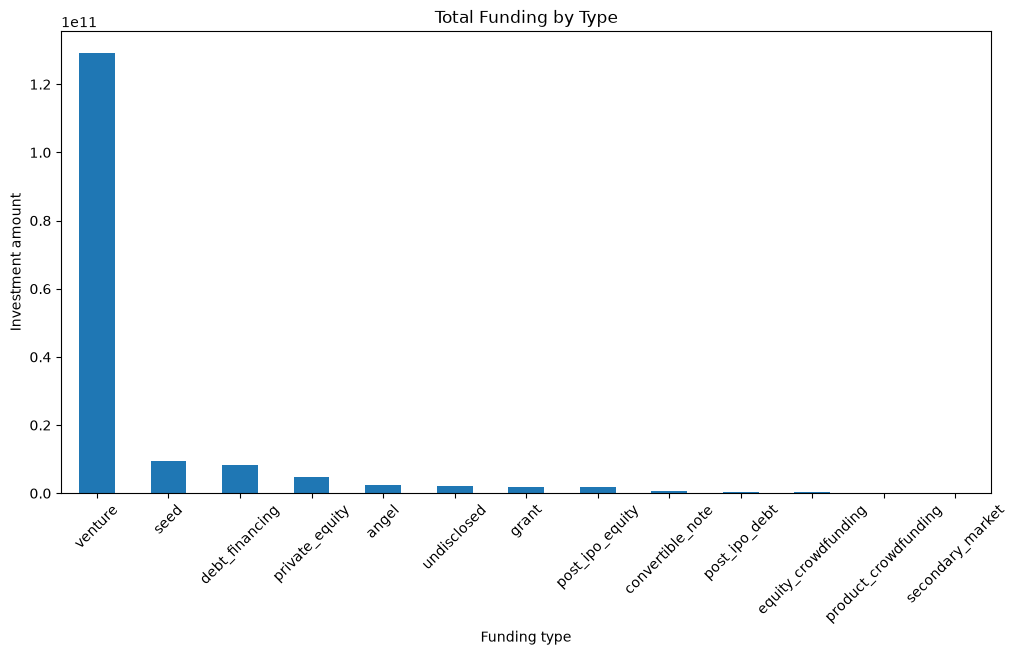

In [75]:
# Create a chart
plt.figure(figsize=(12,6))

funding_sum.plot(kind='bar')

plt.title('Total Funding by Type')
plt.ylabel('Investment amount')
plt.xlabel('Funding type')

plt.xticks(rotation=45)

plt.show()

In [76]:
# Examine the prevalence of different funding types
funding_popular = (new_data[funding_types] > 0).sum().sort_values(ascending=False)
funding_popular

venture                 18820
seed                    13375
debt_financing           3265
angel                    2937
grant                    1003
undisclosed               813
private_equity            634
convertible_note          521
equity_crowdfunding       515
product_crowdfunding      204
post_ipo_equity           164
post_ipo_debt              27
secondary_market            7
dtype: int64

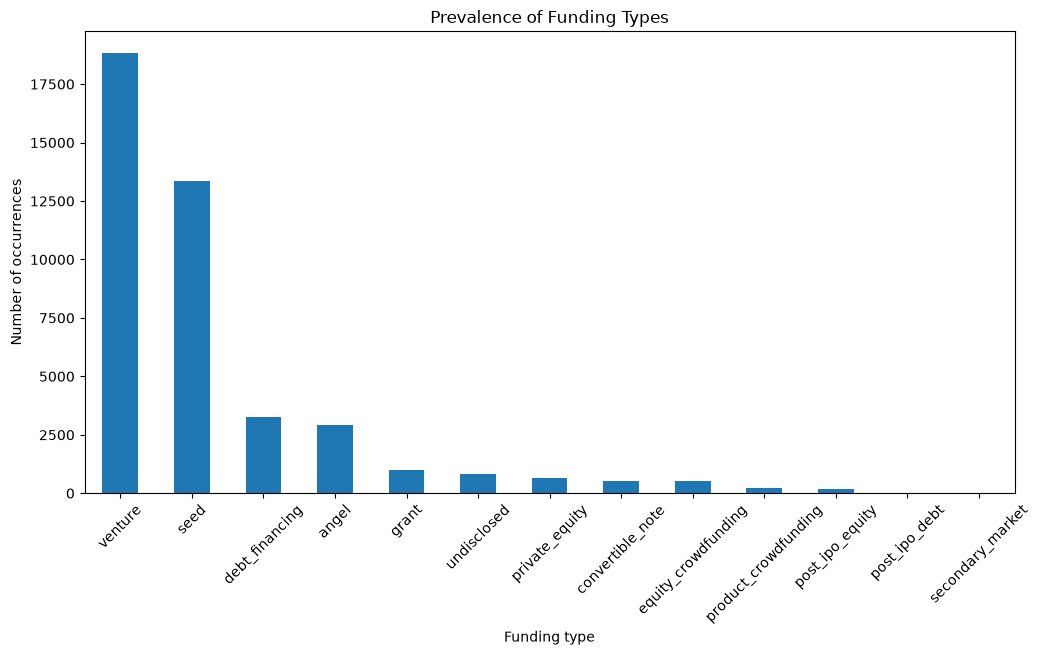

In [77]:
# Plot funding type prevalence using the counts above
plt.figure(figsize=(12,6))
funding_popular.plot(kind='bar')

plt.title('Prevalence of Funding Types')
plt.ylabel('Number of occurrences')
plt.xlabel('Funding type')

plt.xticks(rotation=45)

plt.show()

#### Key findings
- Venture capital accounts for most of the total investment volume, substantially exceeding other funding sources. This highlights the central role of venture capital funds in startup development.
- Seed funding, debt financing, and private equity are also used, but their total volumes are substantially lower. Other funding sources contribute much smaller amounts and play a supporting role.
- Venture funding rounds substantially outnumber other funding types, consistent with the structure of the startup investment market.
- Other forms of financing are considerably less common.

### 3.4 Total funds returned by funding type

In [78]:
return_types = [
'seed',
'venture',
'equity_crowdfunding',
'undisclosed',
'convertible_note',
'debt_financing',
'angel',
'grant',
'private_equity',
'post_ipo_equity',
'post_ipo_debt',
'secondary_market',
'product_crowdfunding'
]

In [79]:
# Calculate total funds returned
returns_sum = cb_returns[return_types].sum().sort_values(ascending=False)
returns_sum

venture                 40578.62
debt_financing           4734.85
private_equity           3587.33
seed                     2382.24
angel                    1509.23
post_ipo_equity          1104.96
undisclosed               730.88
post_ipo_debt              91.03
convertible_note           34.79
secondary_market            5.20
equity_crowdfunding         3.83
product_crowdfunding        1.86
grant                       0.00
dtype: float64

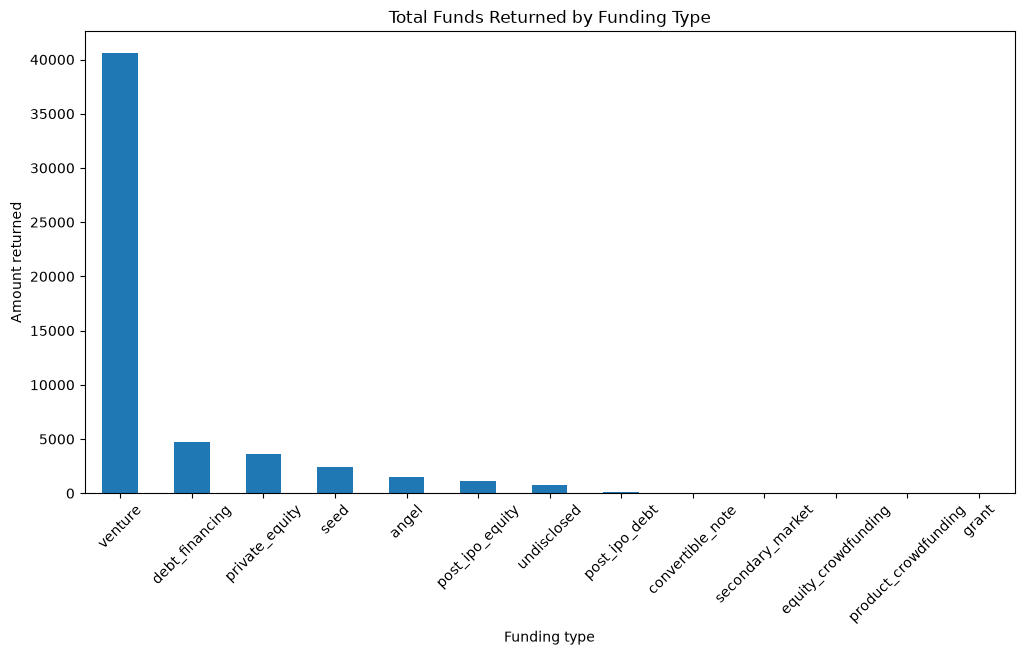

In [80]:
# Create a chart
plt.figure(figsize=(12,6))
returns_sum.plot(kind='bar')

plt.title('Total Funds Returned by Funding Type')
plt.ylabel('Amount returned')
plt.xlabel('Funding type')

plt.xticks(rotation=45)

plt.show()

In [81]:
# Check the dataset size after preprocessing
new_data.shape

(35588, 44)

In [82]:
# Inspect descriptive statistics for investment amounts
new_data['funding_total_usd'].describe()

count    3.558800e+04
mean     4.534501e+06
std      8.033385e+06
min      1.000000e+00
25%      2.500000e+05
50%      1.310000e+06
75%      5.000000e+06
max      7.498919e+07
Name: funding_total_usd, dtype: float64

#### Key findings
- Venture capital accounts for the largest funding and returned-funds volumes, substantially exceeding other investment types. Seed and angel funding are the most frequently used types, but typically involve smaller amounts.
- Early-stage investments tend to be smaller, while later-stage financing, such as venture capital and private equity, involves substantially larger investments and returned amounts.
- After cleaning the data and removing anomalies, the sample contains 5,344 observations.
- Mean investment is approximately 2.6 million, while the median is much lower, at approximately 800,000, indicating an asymmetric distribution.
- Half of investment amounts fall between 170,000 and 3 million, reflecting the high variability of startup funding.

#### [Back to contents](#main)

## 4. Trend analysis <a class="anchor" id="4-bullet"></a>
Explore annual funding trends in more detail, including funding round sizes, investment growth across market segments, and the ratio of returned funds to funding.

### 4.1 Annual funding trends

In [83]:
# Calculate the average funding round size for each company
new_data['avg_round'] = new_data['funding_total_usd'] / new_data['funding_rounds']
new_data['avg_round']

1        2.000000e+06
2        9.000000e+06
3        2.566667e+06
4        5.400000e+05
7        8.700000e+06
             ...     
49430    1.500000e+06
49433    1.500000e+06
49434    9.000000e+06
49435    2.500000e+05
49437    1.150000e+04
Name: avg_round, Length: 35588, dtype: float64

In [84]:
# Calculate the typical round size by year
avg_round_year = new_data.groupby('funding_year')['avg_round'].median()
avg_round_year

funding_year
2000    2.250000e+06
2001    1.570886e+06
2002    3.225000e+06
2003    1.500000e+06
2004    3.000000e+06
2005    4.500000e+06
2006    3.900000e+06
2007    2.879167e+06
2008    2.170744e+06
2009    1.498475e+06
2010    1.250000e+06
2011    8.676850e+05
2012    6.860000e+05
2013    5.590000e+05
2014    5.606250e+05
Name: avg_round, dtype: float64

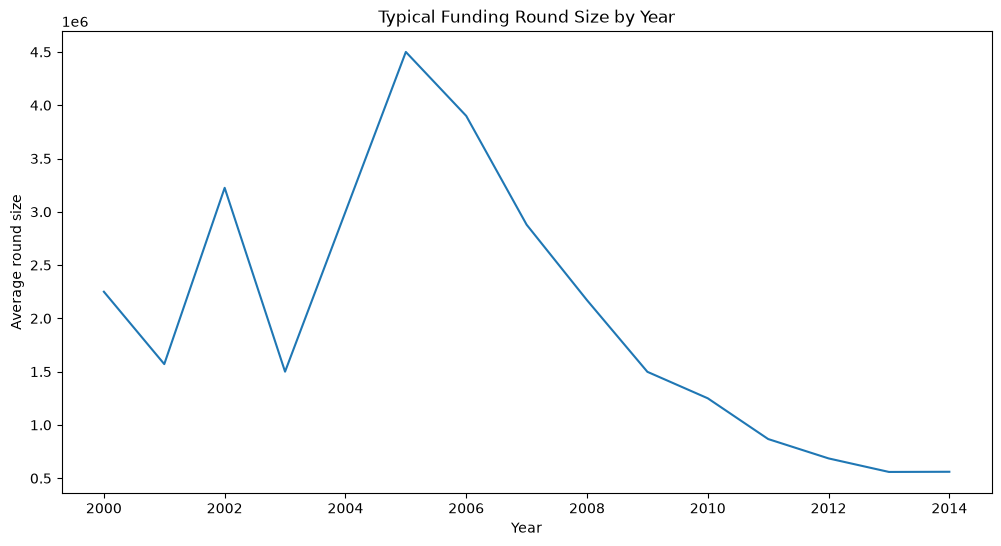

In [85]:
# Plot the typical round size by year
plt.figure(figsize=(12,6))

avg_round_year.plot()

plt.title('Typical Funding Round Size by Year')
plt.ylabel('Average round size')
plt.xlabel('Year')

plt.show()

In [86]:
# Calculate the number of rounds by year
rounds_year = new_data.groupby('funding_year')['funding_rounds'].sum()
rounds_year

funding_year
2000      113.0
2001       66.0
2002       98.0
2003      125.0
2004      181.0
2005      948.0
2006     1849.0
2007     2842.0
2008     3663.0
2009     4617.0
2010     6136.0
2011     7578.0
2012     9707.0
2013    12880.0
2014     7122.0
Name: funding_rounds, dtype: float64

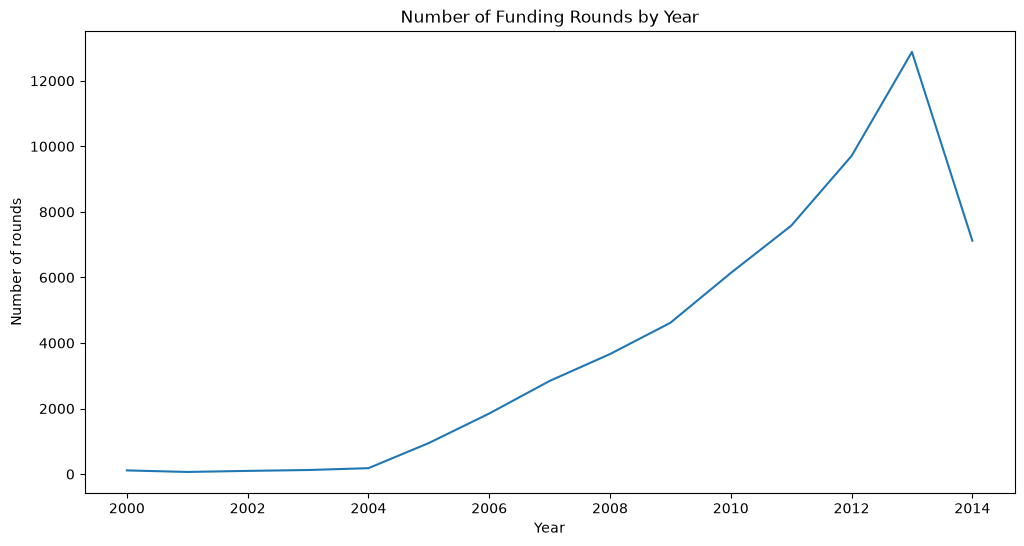

In [87]:
# Plot the number of rounds by year
plt.figure(figsize=(12,6))

rounds_year.plot()

plt.title('Number of Funding Rounds by Year')
plt.ylabel('Number of rounds')
plt.xlabel('Year')

plt.show()

#### Key findings
- The number of funding rounds increased substantially between 2000 and 2013.
- Activity peaked in 2013.
- Meanwhile, the median round size gradually declined after the mid-2000s. This may indicate an expanding startup investment market, with more deals but smaller average deal sizes.

### 4.2 Total funding trends in mass-market segments that grew in 2014

In [88]:
full_data = cb_investments.copy()

In [89]:
# Extract the funding year
full_data['funding_year'] = pd.to_datetime(full_data['mid_funding_at'], errors='coerce').dt.year

# Filter to the period starting with at least 50 rounds per year
full_data = full_data[full_data['funding_year'] >= start_year]

# Exclude unknown markets
full_data = full_data[full_data['market'] != 'unknown']

# Keep only mass-market segments
mass_data = full_data[~full_data['market'].isin(['mid', 'niche'])].copy()

pivot_funding = mass_data.pivot_table(
    index='funding_year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum')

In [90]:
# Identify growing segments
growing_segments = pivot_funding.loc[2014] > pivot_funding.loc[2013]
growing_segments = growing_segments[growing_segments].index
growing_segments

Index(['Apps', 'Consulting', 'Design', 'Enterprise Software', 'Entertainment',
       'Finance', 'Hospitality', 'Internet', 'Manufacturing', 'Medical',
       'Nonprofits', 'Real Estate', 'Software', 'Sports', 'Startups', 'Video'],
      dtype='str', name='market')

In [91]:
# Examine growing segments by year
pivot_growing = pivot_funding[growing_segments]
pivot_growing.head()

market,Apps,Consulting,Design,Enterprise Software,Entertainment,Finance,Hospitality,Internet,Manufacturing,Medical,Nonprofits,Real Estate,Software,Sports,Startups,Video
funding_year,,,,,,,,,,,,,,,,
2000,NaN,69400000.0,NaN,4711445.0,97600000.0,15000000.0,NaN,10000000.0,56659310.0,24000000.0,6500000.0,2500000.0,384632640.0,NaN,NaN,NaN
2001,NaN,NaN,NaN,2180175.0,NaN,127620230.0,NaN,NaN,2368582.0,NaN,NaN,NaN,168386279.0,NaN,NaN,NaN
2002,NaN,NaN,NaN,172664356.0,NaN,NaN,NaN,1100000.0,255700000.0,NaN,NaN,5275000.0,150126395.0,200000.0,NaN,NaN
2003,NaN,NaN,NaN,7669661.0,NaN,25320000.0,NaN,180500000.0,4269608.0,NaN,NaN,6292200.0,400208935.0,NaN,NaN,5000000.0
2004,NaN,62791270.0,NaN,51270000.0,NaN,NaN,NaN,10500000.0,3000000.0,NaN,NaN,NaN,311710273.0,NaN,NaN,14704000.0


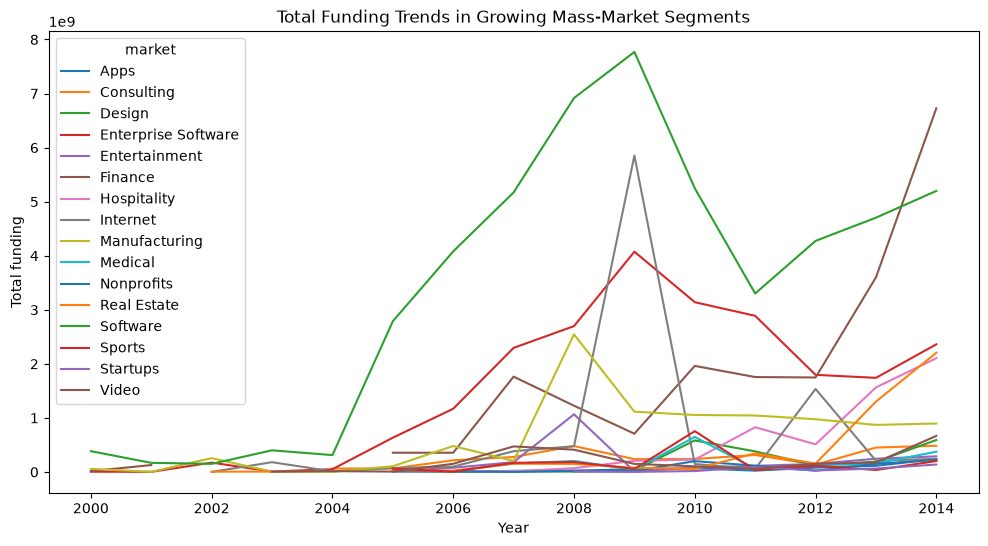

In [92]:
# Visualize the results
plt.figure(figsize=(12,6))

pivot_growing.plot(ax=plt.gca())

plt.title('Total Funding Trends in Growing Mass-Market Segments')
plt.xlabel('Year')
plt.ylabel('Total funding')

plt.show()

#### Key findings
- Total funding increased sharply in most mass-market segments between 2005 and 2008, followed by a decline likely associated with the global financial crisis of 2008–2009.
- Funding gradually recovered in subsequent years. Several segments recorded higher investment in 2014 than in 2013.
- Design and Internet recorded the largest total investment volumes. This may be associated with the popularity of digital platforms and SaaS solutions, which attract substantial venture capital.
- The Internet segment shows a sharp funding spike around 2009, likely driven by a few large investment rounds.

### 4.3 Annual trends in the ratio of returned funds to funding by type

In [93]:
# Extract funding years
cb_investments['funding_year'] = pd.to_datetime(
    cb_investments['mid_funding_at'], errors='coerce').dt.year

In [94]:
funding_by_year = cb_investments.groupby('funding_year')[
    ['venture','debt_financing','private_equity','seed','angel']].sum()

In [95]:
returns_by_year = cb_returns.groupby('year')[
    ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']].sum() * 1_000_000

In [96]:
# Remove outliers and anomalous years
share_returns = returns_by_year.div(funding_by_year + 1e-60)

share_returns[share_returns > 1.5] = np.nan
share_returns = share_returns.dropna(how='all')
share_returns

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,0.027630,0.126147,0.000000,0.399218,0.246489
2001,0.019571,0.069259,0.000000,0.109095,1.180000
2002,0.195638,0.015884,0.001309,0.361557,0.426250
2003,0.115517,0.051171,0.058408,0.423849,0.071003
2004,0.148640,0.081533,0.012659,0.312546,0.793861
2005,0.208573,0.046765,0.001767,0.510741,0.481791
2006,0.132364,0.035107,0.006846,0.596329,0.531152
2007,0.092979,0.043532,0.010694,0.241932,0.629818
2008,0.051409,0.075356,0.011961,0.250211,0.372000


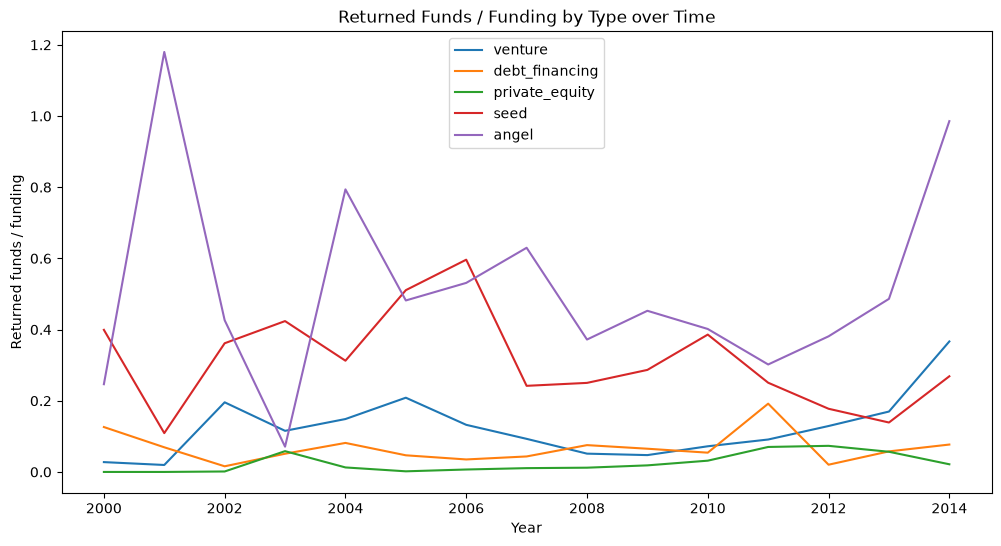

In [97]:
# Plot trends in the ratio of returned funds to funding by type
plt.figure(figsize=(12,6))

share_returns.plot(ax=plt.gca())

plt.title('Returned Funds / Funding by Type over Time')
plt.xlabel('Year')
plt.ylabel('Returned funds / funding')

plt.show()

#### Key findings
- The number of funding rounds increased substantially between 2000 and 2013.
- Activity peaked in 2013.
- Angel funding has the highest ratios of returned funds to funding, but also substantial volatility, reflecting the high risk of early-stage investments.
- Seed investments also show relatively high ratios, although the measure is unstable because of the uncertainty surrounding early-stage projects.

#### [Back to contents](#main)

## 5. Conclusions and recommendations <a class="anchor" id="5-bullet"></a>

##### 1. Which industry and funding type appear most attractive?
- Based on this analysis, technology industries, particularly Software and Internet, appear attractive due to their high funding volumes and sustained investment activity.
- Venture capital may be a suitable funding type because it provides substantial investment volumes and shows relatively stable patterns in returned funds.

##### 2. Main findings
- Technology segments show some of the most notable funding growth. Design has the largest investment volume and the highest funding levels through much of the study period. Software, Internet, and Enterprise Software also show sustained growth.
- Venture capital accounts for the largest investment volume, while seed and angel financing are used at earlier stages of company development.
- The ratio of returned funds to funding is more stable for venture capital, while angel and seed investments show greater volatility.

##### 3. Steps completed
- Preprocessed the data: removed duplicates, handled missing values, and checked data types.
- Analyzed funding distributions and the prevalence of different investment types.
- Examined annual trends in average funding round size and the number of rounds.
- Identified mass-market segments and analyzed their funding trends.
- Calculated the ratio of returned funds to funding by funding type and examined changes over time.
- The tables were not merged directly because they have different levels of aggregation. Investment analysis used `cb_investments`, while returned-funds analysis used aggregated data from `cb_returns`. This avoided unnecessary duplication and made the calculations more efficient.

##### 4. Consistency of the results
- The results are broadly consistent. Segments with growing funding volumes also show strong investment activity and an increasing number of funding rounds. Common funding types, such as venture capital and debt financing, show relatively stable patterns in returned funds. These findings support the potential of technology market segments as investment opportunities.
- Common funding types, including venture capital, debt financing, and seed funding, also show rising ratios of returned funds to funding in the final years of the study period. This further supports the potential of technology market segments.

#### [Back to contents](#main)